# Day 4 : Exploratory Data Analysis, Visualization & Storytelling

## Part 1 : EDA

In [1]:
## Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
## Load the Dataset
df = pd.read_csv("dataset.csv")

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


## Dataset Structure

In [4]:
df.shape

(17643, 21)

In [5]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17643 entries, 0 to 17642
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17643 non-null  int64  
 1   track_id          17643 non-null  object 
 2   artists           17643 non-null  object 
 3   album_name        17643 non-null  object 
 4   track_name        17642 non-null  object 
 5   popularity        17642 non-null  float64
 6   duration_ms       17642 non-null  float64
 7   explicit          17642 non-null  object 
 8   danceability      17642 non-null  float64
 9   energy            17642 non-null  float64
 10  key               17642 non-null  float64
 11  loudness          17642 non-null  float64
 12  mode              17642 non-null  float64
 13  speechiness       17642 non-null  float64
 14  acousticness      17642 non-null  float64
 15  instrumentalness  17642 non-null  float64
 16  liveness          17642 non-null  float6

## Numerical and Categorical Features

In [7]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
Index(['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

Categorical Features:
Index(['track_id', 'artists', 'album_name', 'track_name', 'explicit',
       'track_genre'],
      dtype='object')


## Descriptive Statistical Analysis

In [8]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,17643.000000,17642.000000,1.764200e+04,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000,17642.00000,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000
mean,8821.000000,32.802914,2.385319e+05,0.555609,0.582111,5.311189,-9.533904,0.664664,0.069471,0.37066,0.232542,0.192700,0.467661,121.265151,3.891679
std,5093.239735,21.659387,1.413564e+05,0.181560,0.272656,3.563188,5.746593,0.472121,0.073102,0.35935,0.358380,0.168277,0.267486,29.144801,0.426836
min,0.000000,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.808000,0.000000,0.000000,0.00000,0.000000,0.011600,0.000000,0.000000,0.000000
25%,4410.500000,16.000000,1.731470e+05,0.437000,0.373000,2.000000,-11.483000,0.000000,0.034100,0.01640,0.000000,0.095300,0.241000,99.963000,4.000000
50%,8821.000000,33.000000,2.212290e+05,0.570000,0.609000,5.000000,-8.012000,1.000000,0.044500,0.25600,0.000712,0.123000,0.449000,121.689000,4.000000
75%,13231.500000,50.000000,2.759682e+05,0.689000,0.824750,9.000000,-5.735250,1.000000,0.069400,0.72100,0.496000,0.237000,0.685000,139.324500,4.000000
max,17642.000000,93.000000,4.789026e+06,0.981000,1.000000,11.000000,4.532000,1.000000,0.943000,0.99600,0.995000,0.995000,0.995000,243.372000,5.000000


In [9]:
df.describe(include='object')

,track_id,artists,album_name,track_name,explicit,track_genre
count,17643,17643,17643,17642,17642,17642
unique,16617,5576,9258,14622,2,18
top,6JMRXqVpDD1Xu2lAoFOVbS,my little airport,Mozart: A Night of Classics,Run Rudolph Run,False,acoustic
freq,3,171,81,39,16721,1000


In [10]:
## Missing Values Analysis
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,1
popularity,1
duration_ms,1
explicit,1
danceability,1
energy,1


In [11]:
## Duplicate Records Analysis
df.duplicated().sum()

np.int64(0)

In [12]:
## Relationship Between Features
df.corr(numeric_only=True)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,-0.051666,-0.030754,0.149421,-0.166758,-0.029381,-0.177419,0.044695,0.076247,0.134521,0.123148,-0.017634,-0.004409,-0.022954,-0.004485
popularity,-0.051666,1.000000,-0.106140,0.006553,-0.098854,-0.030604,0.044996,0.007778,-0.003743,0.069413,-0.157304,-0.006774,-0.104184,-0.014999,0.013657
duration_ms,-0.030754,-0.106140,1.000000,-0.067587,0.157113,0.008511,0.081433,-0.048041,-0.033813,-0.185920,0.071953,0.030467,-0.126127,0.043406,0.025729
danceability,0.149421,0.006553,-0.067587,1.000000,0.162894,0.031681,0.270386,-0.016313,0.164483,-0.176312,-0.235253,-0.084691,0.528582,-0.046937,0.196977
energy,-0.166758,-0.098854,0.157113,0.162894,1.000000,0.061406,0.785204,-0.083966,0.176475,-0.795089,-0.182571,0.187701,0.287584,0.230611,0.178105
key,-0.029381,-0.030604,0.008511,0.031681,0.061406,1.000000,0.043404,-0.146411,0.019910,-0.050847,-0.011758,0.005150,0.035507,0.012962,0.010350
loudness,-0.177419,0.044996,0.081433,0.270386,0.785204,0.043404,1.000000,-0.012064,0.119420,-0.642202,-0.456809,0.127557,0.274179,0.191514,0.177297
mode,0.044695,0.007778,-0.048041,-0.016313,-0.083966,-0.146411,-0.012064,1.000000,-0.067917,0.116376,-0.089513,0.013780,0.035655,0.008609,-0.004452
speechiness,0.076247,-0.003743,-0.033813,0.164483,0.176475,0.019910,0.119420,-0.067917,1.000000,-0.101273,-0.085661,0.084782,0.095176,0.067814,0.040245
acousticness,0.134521,0.069413,-0.185920,-0.176312,-0.795089,-0.050847,-0.642202,0.116376,-0.101273,1.000000,0.135615,-0.107739,-0.163049,-0.192410,-0.159391


# Part 2 : Data Visualization & Storytelling

## Visualization 1: Top 10 Music Genres

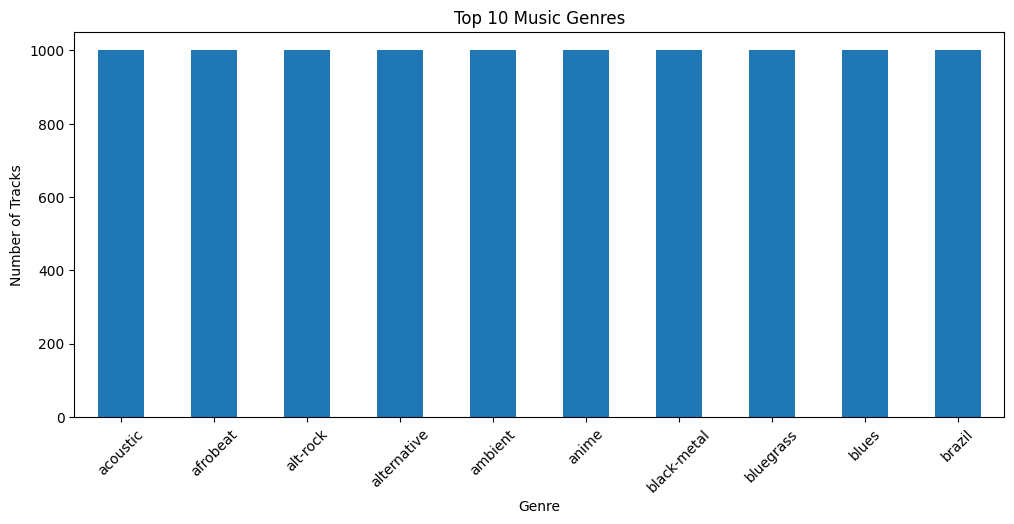

In [13]:
plt.figure(figsize=(12,5))

df['track_genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Music Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)

plt.show()

### Insight

The dataset contains tracks from many genres, but a few genres have significantly more songs than others, indicating an uneven distribution of music genres.

## Visualization 2: Track Popularity Distribution

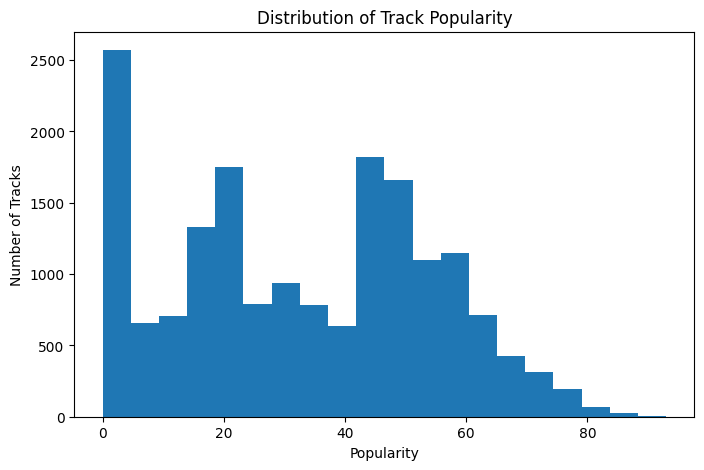

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df['popularity'], bins=20)

plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")

plt.show()

### Insight

Most tracks have moderate popularity, while only a small number of tracks achieve very high popularity.

## Visualization 3: Correlation Heatmap

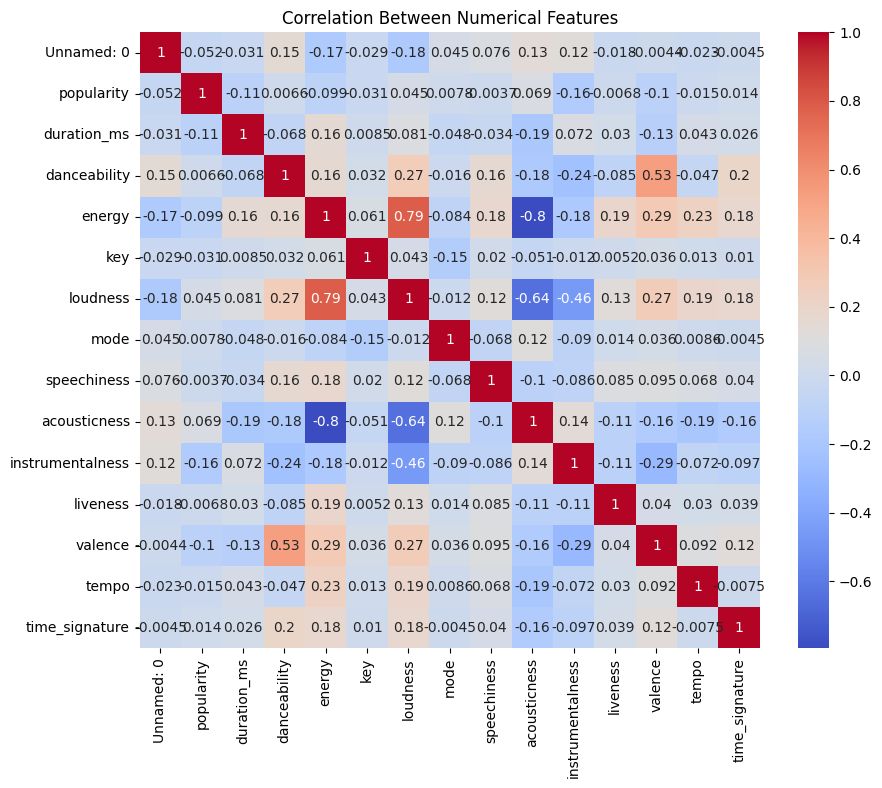

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Numerical Features")

plt.show()

### Insight

The heatmap helps identify relationships between numerical features such as energy, danceability, loudness, and popularity.

## Visualization 4: Energy vs Danceability

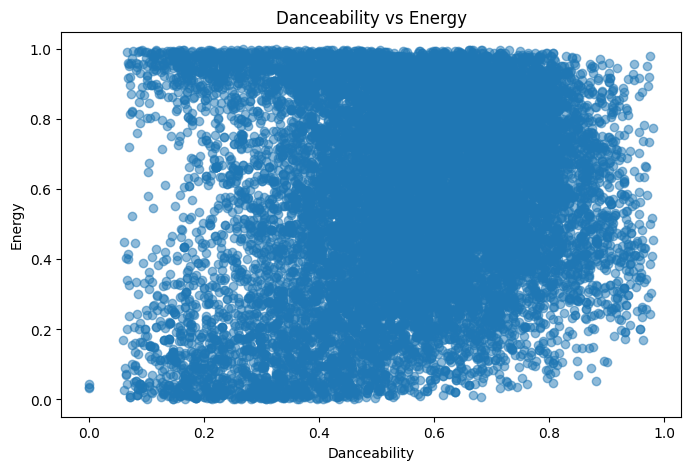

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['danceability'],
    df['energy'],
    alpha=0.5
)

plt.title("Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")

plt.show()

### Insight

Songs with higher danceability often have higher energy, although there is considerable variation across tracks.

## Visualization 5: Popularity by Explicit Content

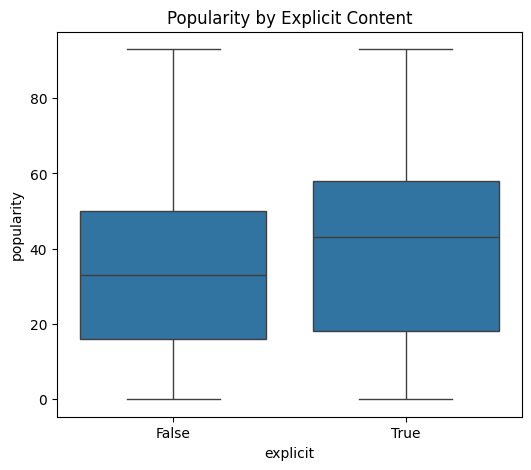

In [17]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='explicit',
    y='popularity',
    data=df
)

plt.title("Popularity by Explicit Content")

plt.show()

### Insight

The popularity distribution of explicit and non-explicit songs overlaps, suggesting that explicit content alone does not determine a song's popularity.

## Visualization 6: Popularity Across Top Music Genres

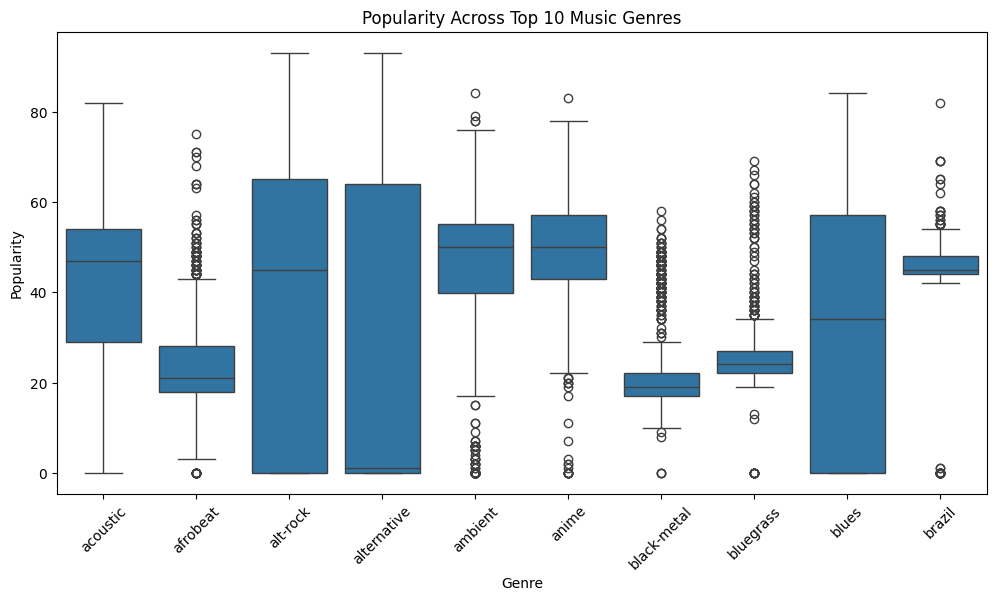

In [19]:
top_genres = df['track_genre'].value_counts().head(10).index

genre_df = df[df['track_genre'].isin(top_genres)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=genre_df,
    x='track_genre',
    y='popularity'
)

plt.title("Popularity Across Top 10 Music Genres")
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.xticks(rotation=45)

plt.show()

### Insight

Popularity varies across different music genres. Some genres have consistently higher popularity, while others show a wider spread, indicating greater variation in listener preferences.

# Overall Conclusions

The Spotify Tracks Dataset provides valuable insights into the characteristics of songs available on the platform. Through exploratory data analysis and visualizations, it was observed that music genres are unevenly distributed, with a few genres containing a larger number of tracks. Most songs have moderate popularity, while only a small percentage achieve very high popularity. Features such as danceability and energy show positive relationships, and explicit content does not significantly affect a track's popularity. Overall, the analysis demonstrates how data visualization can reveal meaningful patterns and trends that can support future music recommendation systems and machine learning applications.